# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [4]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [5]:
# Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
df ['title_lenght']= df['title'].apply (len)
df

,star_rating,title,content_rating,genre,duration,actors_list,title_lenght
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...",24
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']",13
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv...",22
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E...",15
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L....",12
...,...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G...",7
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma...",27
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo...",47
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr...",11


In [6]:
# Calcula media, mediana y moda de la columna 'title_length'

print (f'Media {df.title_lenght.mean()}')
print (f'Mediana {df.title_lenght.median()}')
print (f'Moda {df.title_lenght.mode()[0]}')

Media 15.481103166496425
Mediana 14.0
Moda 12


In [16]:
# Calcula el rango, la varianza y la desviación estándar de 'title_length'
print (f'Rango {df.title_lenght.max() - df.title_lenght.min()}')
print (f'Varianza {df.title_lenght.var()}')
print (f'Desviacion Estandar {df.title_lenght.std()}')

Rango 67
Varianza 72.1067488840288
Desviacion Estandar 8.491569282766807


In [ ]:
# Calcula asimetría y curtosis de la columna 'title_length'
print (f'Asimetria {df.title_lenght.skew()}')
print (f'Kurtosis {df.title_lenght.kurtosis()}')
print (f'Asimetria {skew(df.title_lenght)}')
print (f'Kurtosis {kurtosis(df.title_lenght)}')
#por que los resultados son distintos?

Asimetria 1.5252523464631278
Kurtosis 3.8122887061291544
Asimetria 1.5229143965677572
Kurtosis 3.7867237597626007


In [30]:
# Imprime el título más corto y el título más largo según su longitud
print (f'titulo mas largo: {df.title[int(df.title_lenght.argmax())]}')
print (f'titulo mas corto: {df.title[int(df.title_lenght.argmin())]}')

titulo mas largo: Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb
titulo mas corto: M


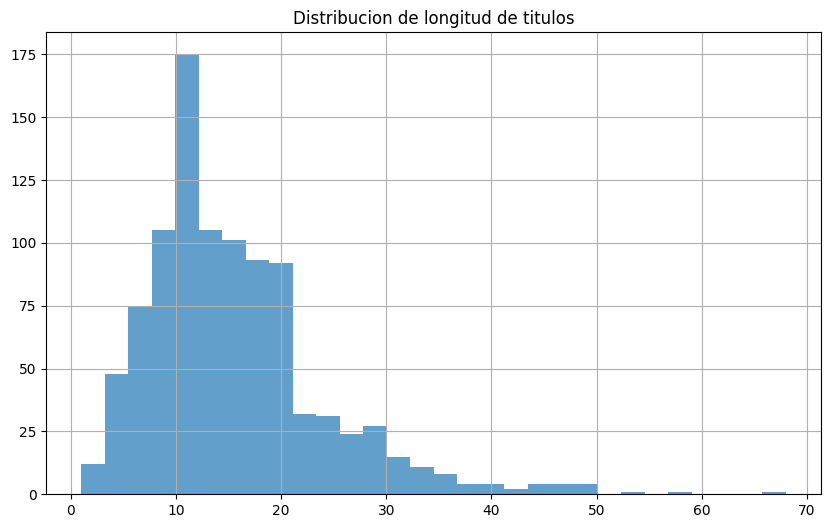

In [35]:
# grafica tus resultados
plt.figure(figsize=(10,6))
plt.hist (df.title_lenght,bins=30,alpha=0.7)
plt.title ("Distribucion de longitud de titulos")
plt.grid(True)
plt.show()

---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


In [14]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]
data = [10, 13, 14, 18, 22]

In [13]:
# Calcula la media de los 5 valores
media = sum(data) / len (data)
print (f'Media: {media}')

Media: 15.4


In [15]:
# Calcula las diferencias al cuadrado con respecto a la media
#metodo de comprension de lista, data es una lista entonces puedo operar con un "for"
suma_diferencias = sum ((x-media)**2 for x in data)
#metodo iterador
acumulador = 0
for x in data: 
    acumulador = acumulador + (x-media)**2
print(f'Suma de Diferenecia: {suma_diferencias}')
print(f'Acumulador: {acumulador}')

Suma de Diferenecia: 87.19999999999999
Acumulador: 87.19999999999999


In [11]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación

varianza_manual = suma_diferencias / len(data)
desviacion_manual = varianza_manual**0.5

print(f'Varianza manual: {varianza_manual}')
print(f'Varianza calculada: {np.var(data)}')
print(f'Desviacion manual: {desviacion_manual}')

Varianza manual: 17.439999999999998
Varianza calculada: 17.439999999999998
Desviacion manual: 4.176122603564219
